# Open-loop error from calibration slide photos

Companion to `test_xmas_tree_x.py`. Put the photos into `IMG_DIR`; they are sorted by
file name, the **first one is the reference** ("before") and every other photo is
compared against it. So e.g. `0_before.jpg`, `1_after.jpg` - or more photos
(`0_before_a`, `0_before_b` without moving in between gives you the noise floor of
the measurement).

The shift is found by cross correlation of the two images (FFT, sub-pixel peak by a
parabola fit). The pixel size is calibrated from the tick period of the horizontal ruler.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

IMG_DIR = Path(".")   # folder with the photos ("." = next to this notebook)
TICK_UM = 10.0        # distance between two small ruler ticks in um  <-- CHECK YOUR SLIDE
PX_PER_TICK = None    # None = measure from the reference image, or set by hand
UM_PER_STEP = None    # optional: stage travel per motor step, to express the error in steps

IMG_DIR.mkdir(exist_ok=True)
files = sorted(p for p in IMG_DIR.iterdir()
               if p.suffix.lower() in (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"))
print(*[p.name for p in files], sep="\n")
assert len(files) >= 2, f"need at least 2 photos in {IMG_DIR.resolve()}"


def load_gray(path):
    im = plt.imread(path).astype(float)
    return im[..., :3].mean(axis=2) if im.ndim == 3 else im


images = [load_gray(p) for p in files]
ref = images[0]
assert all(im.shape == ref.shape for im in images), "photos must all have the same size"

Image_20261002133603729.bmp
Image_20261002143426132.bmp


## Pixel size from the ruler

Autocorrelation of the intensity profile along x (middle rows of the reference image):
the first peak is the tick period in pixels. Check in the plot that the marked peak is
really the small-tick period; if not, set `PX_PER_TICK` by hand above.

tick period = 82.81 px (used: 82.81) -> 0.1208 um/px


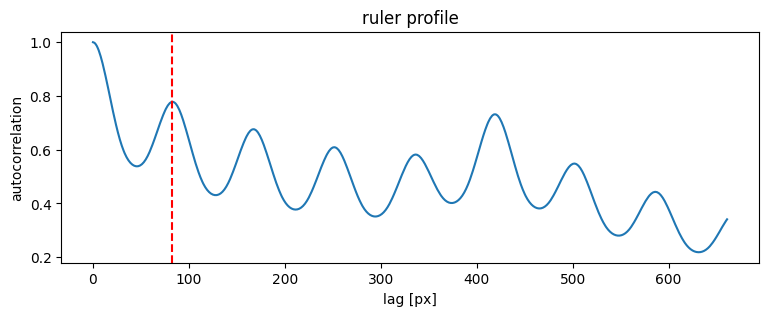

In [18]:
def tick_period(im, min_lag=5):
    h = im.shape[0]
    prof = im[int(h * 0.45):int(h * 0.55)].mean(axis=0)
    prof = (prof - prof.mean()) * np.hanning(prof.size)
    ac = np.fft.irfft(np.abs(np.fft.rfft(prof, 2 * prof.size)) ** 2)[:prof.size // 2]
    ac /= ac[0]
    peaks = [i for i in range(min_lag, ac.size - 1)
             if ac[i] > ac[i - 1] and ac[i] >= ac[i + 1] and ac[i] > 0.3]
    i = peaks[0]
    # parabola through the 3 points around the peak
    return i + 0.5 * (ac[i - 1] - ac[i + 1]) / (ac[i - 1] - 2 * ac[i] + ac[i + 1]), ac


period, ac = tick_period(ref)
px_per_tick = PX_PER_TICK or period
um_per_px = TICK_UM / px_per_tick
print(f"tick period = {period:.2f} px (used: {px_per_tick:.2f}) -> {um_per_px:.4f} um/px")

plt.figure(figsize=(9, 3))
plt.plot(ac[:int(period * 8)])
plt.axvline(period, color="r", ls="--")
plt.xlabel("lag [px]"); plt.ylabel("autocorrelation"); plt.title("ruler profile")
plt.show()

## Shift of every photo relative to the first one

`dx`, `dy` = how far the image content moved (positive = right / down in the photo).

In [19]:
def measure_shift(ref, img, highpass_px=100):
    """Cross correlation; returns (dx, dy) of img relative to ref and the correlation map."""
    h, w = ref.shape
    win = np.outer(np.hanning(h), np.hanning(w))
    A = np.fft.fft2((ref - ref.mean()) * win)
    B = np.fft.fft2((img - img.mean()) * win)
    X = np.conj(A) * B
    # drop the slow background (vignetting does not move with the stage)
    fy = np.fft.fftfreq(h)[:, None]
    fx = np.fft.fftfreq(w)[None, :]
    X[np.hypot(fx, fy) < 1 / highpass_px] = 0
    cc = np.fft.ifft2(X).real
    py, px = np.unravel_index(np.argmax(cc), cc.shape)

    def subpixel(cm, c0, cp):
        return 0.5 * (cm - cp) / (cm - 2 * c0 + cp)

    dy = py + subpixel(cc[py - 1, px], cc[py, px], cc[(py + 1) % h, px])
    dx = px + subpixel(cc[py, px - 1], cc[py, px], cc[py, (px + 1) % w])
    if dy > h / 2:
        dy -= h
    if dx > w / 2:
        dx -= w
    return dx, dy, np.fft.fftshift(cc)


results = []
print(f"{'photo':<28} {'dx [px]':>9} {'dy [px]':>9} {'dx [um]':>9} {'dy [um]':>9} {'|d| [um]':>9}"
      + (f" {'|d| [steps]':>12}" if UM_PER_STEP else ""))
for p, im in zip(files[1:], images[1:]):
    dx, dy, cc = measure_shift(ref, im)
    d_um = np.hypot(dx, dy) * um_per_px
    results.append((p, im, dx, dy, cc))
    print(f"{p.name:<28} {dx:>9.2f} {dy:>9.2f} {dx * um_per_px:>9.2f} {dy * um_per_px:>9.2f} {d_um:>9.2f}"
          + (f" {d_um / UM_PER_STEP:>12.1f}" if UM_PER_STEP else ""))
print(f"\n(reference: {files[0].name}; one tick = {px_per_tick:.1f} px - a shift close to a "
      "multiple of that may be a wrong correlation peak, check the overlay below)")

photo                          dx [px]   dy [px]   dx [um]   dy [um]  |d| [um]
Image_20261002143426132.bmp       5.99     -1.86      0.72     -0.22      0.76

(reference: Image_20261002133603729.bmp; one tick = 82.8 px - a shift close to a multiple of that may be a wrong correlation peak, check the overlay below)


## Visual check

Left: overlay of the image centre, reference in red, photo in cyan - where they agree it is
grey/black, a shift shows up as coloured fringes. Right: correlation peak (should be one clean maximum).

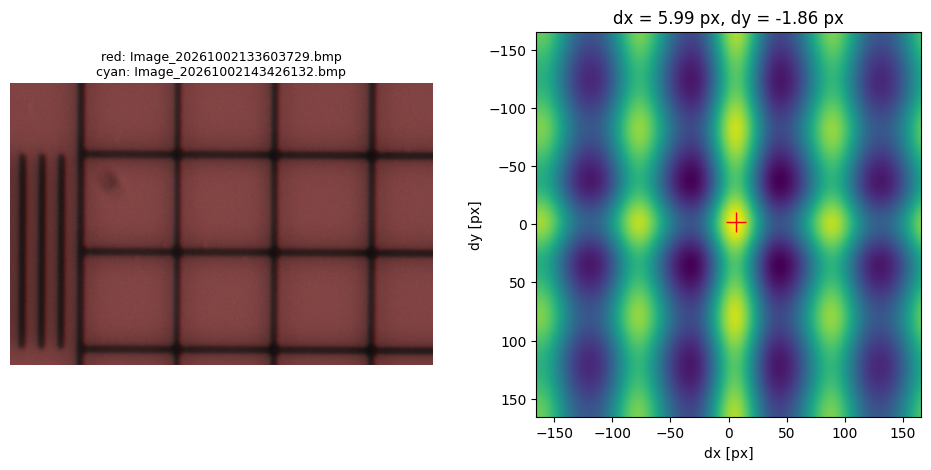

In [20]:
def norm(a):
    return (a - a.min()) / (a.max() - a.min())


h, w = ref.shape
ys, xs = slice(h // 2 - h // 6, h // 2 + h // 6), slice(w // 2 - w // 6, w // 2 + w // 6)
z = int(max(30, 2 * px_per_tick))
for p, im, dx, dy, cc in results:
    fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 5))
    a0.imshow(np.dstack([norm(ref[ys, xs]), norm(im[ys, xs]), norm(im[ys, xs])]))
    a0.set_title(f"red: {files[0].name}\ncyan: {p.name}", fontsize=9); a0.axis("off")
    a1.imshow(cc[h // 2 - z:h // 2 + z + 1, w // 2 - z:w // 2 + z + 1],
              extent=(-z - .5, z + .5, z + .5, -z - .5), cmap="viridis")
    a1.plot(dx, dy, "r+", ms=14)
    a1.set_title(f"dx = {dx:.2f} px, dy = {dy:.2f} px"); a1.set_xlabel("dx [px]"); a1.set_ylabel("dy [px]")
    plt.show()